In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import types
import copy
from contextlib import contextmanager

import ssl
import certifi
import copy
import matplotlib.pyplot as plt

# Setup

This code was generated with heavy help by Gemini.

## Load Data

In [2]:
def get_cifar_datasets(
    data_dir="./data", batch_size=128, test_samples=10000, seed=None
):
  """Loads CIFAR-10 datasets and returns training and test DataLoaders.

  Parameters:
      data_dir (str): Directory to store/download the CIFAR-10 data.
      batch_size (int): Batch size for the DataLoaders.
      test_samples (int): Number of samples to include in the test set.
      seed (int, optional): Random seed for reproducibility.

  Returns:
      tuple: (train_loader, test_loader)
  """
  # Create a secure SSL context using certifi to prevent SSL certificate verification errors
  ssl_context = ssl.create_default_context(cafile=certifi.where())
  old_context = ssl._create_default_https_context
  ssl._create_default_https_context = lambda: ssl_context

  try:
    if seed is not None:
      torch.manual_seed(seed)
      generator = torch.Generator().manual_seed(seed)
    else:
      generator = None

    # CIFAR-10 standard normalization channels
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ])

    try:
      train_dataset = datasets.CIFAR10(
          data_dir, train=True, download=True, transform=transform_train
      )
      test_dataset = datasets.CIFAR10(
          data_dir, train=False, download=True, transform=transform_test
      )
    except Exception as e:
      raise RuntimeError(
          f"{e} Could not download CIFAR-10 automatically. "
          "You will need to manually download or check your connection."
      ) from e

    # Subsample test set if test_samples < total test dataset length
    if test_samples < len(test_dataset):
      test_dataset, _ = random_split(
          test_dataset,
          [test_samples, len(test_dataset) - test_samples],
          generator=generator,
      )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )

    return train_loader, test_loader

  finally:
    # Restore global HTTPS context
    ssl._create_default_https_context = old_context

## Initializing CIFAR

[https://github.com/modestyachts/CIFAR-10.1/tree/master](https://github.com/modestyachts/CIFAR-10.1/tree/master)

CIFAR10.1 OOD samples: 2000


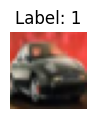

In [3]:
cifar_images = np.load("data/cifar10.1_v6_data.npy")
cifar_labels = np.load("data/cifar10.1_v6_labels.npy")

# Use the same preprocessing as CIFAR-10 test data
cifar_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
    ),
])

if cifar_images.ndim != 4 or cifar_images.shape[-1] != 3:
    raise ValueError(f"Expected CIFAR images in NHWC format, got shape {cifar_images.shape}")

cifar_images = torch.stack([cifar_transform_test(img) for img in cifar_images], dim=0)
cifar_labels = torch.from_numpy(cifar_labels).long()

# Keep variable names used later in the notebook
cifar_test_ds = torch.utils.data.TensorDataset(cifar_images, cifar_labels)

cifar_loader = DataLoader(
    cifar_test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"CIFAR10.1 OOD samples: {len(cifar_test_ds)}")

# Plot one example
img, label = cifar_test_ds[200]
mean = torch.tensor([0.4914, 0.4822, 0.4465], dtype=img.dtype).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616], dtype=img.dtype).view(3, 1, 1)
img_vis = (img * std + mean).clamp(0.0, 1.0)
plt.figure(figsize=(1, 1))
plt.imshow(img_vis.permute(1, 2, 0).cpu().numpy())
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [4]:
from onnx2pytorch import ConvertModel

import json_to_pytorch

import attack

## PyTorch Chebyshev Evaluation

In [5]:
def chebval_torch(x: torch.Tensor, coeffs: torch.Tensor) -> torch.Tensor:
    """Evaluates Chebyshev series Tn(x) via Clenshaw recurrence."""
    n = coeffs.numel()
    if n == 0:
      raise ValueError(
          "Polynomial coefficients are empty. Fit the activation first."
      )
    if n == 1:
      return torch.full_like(x, coeffs[0])
    
    b_k2 = torch.zeros_like(x)
    b_k1 = torch.zeros_like(x)
    
    for i in range(n - 1, 0, -1):
      c_k = coeffs[i]
      b_k = c_k + 2.0 * x * b_k1 - b_k2
      b_k2 = b_k1
      b_k1 = b_k
    
    return coeffs[0] + x * b_k1 - b_k2

## PolySiLU Activation

In [6]:
class PolySiLU(nn.Module):
  """Dual-mode SiLU module: executes exact SiLU or Chebyshev polynomial approximation in pure PyTorch."""

  def __init__(self, degree: int = 127):
    super().__init__()
    self.degree = degree
    self.exact_act = nn.SiLU()
    self.use_poly = False

    # 1. Pre-allocate degree + 1 coefficients (degree 127 = 128 coefficients)
    self.register_buffer("coeffs", torch.empty(degree + 1, dtype=torch.float32))
    self.register_buffer(
        "prescale", torch.tensor(1.0, dtype=torch.float32)
    )
    self.register_buffer(
        "constant", torch.tensor(0.0, dtype=torch.float32)
    )
    self.register_buffer("fused", torch.tensor(False, dtype=torch.bool))
    self.register_buffer(
        "input_min", torch.tensor(0.0, dtype=torch.float32)
    )
    self.register_buffer(
        "input_max", torch.tensor(0.0, dtype=torch.float32)
    )
    self.register_buffer("is_fitted", torch.tensor(False, dtype=torch.bool))

  def _load_from_state_dict(
      self,
      state_dict,
      prefix,
      local_metadata,
      strict,
      missing_keys,
      unexpected_keys,
      error_msgs,
  ):
    """Automatically resizes local buffers if state_dict tensor dimensions differ."""
    coeffs_key = prefix + "coeffs"
    if coeffs_key in state_dict:
      saved_coeffs = state_dict[coeffs_key]
      if self.coeffs.shape != saved_coeffs.shape:
        # Resize buffer to match checkpoint before PyTorch's strict shape check
        self.coeffs = torch.empty_like(saved_coeffs)

    super()._load_from_state_dict(
        state_dict,
        prefix,
        local_metadata,
        strict,
        missing_keys,
        unexpected_keys,
        error_msgs,
    )

  def set_mode(self, use_poly: bool = True):
    self.use_poly = use_poly

  def load_orion_state(self, orion_act_module):
    """Imports polynomial coefficients, scalings, and bounds from an Orion activation instance."""
    if hasattr(orion_act_module, "coeffs") and orion_act_module.coeffs is not None:
      coeffs_tensor = torch.as_tensor(
          orion_act_module.coeffs, dtype=torch.float32
      )
      self.coeffs = coeffs_tensor.clone().detach()

    if hasattr(orion_act_module, "prescale"):
      self.prescale = torch.tensor(
          float(orion_act_module.prescale), dtype=torch.float32
      )
    if hasattr(orion_act_module, "constant"):
      self.constant = torch.tensor(
          float(orion_act_module.constant), dtype=torch.float32
      )
    if hasattr(orion_act_module, "fused"):
      self.fused = torch.tensor(
          bool(orion_act_module.fused), dtype=torch.bool
      )

    if hasattr(orion_act_module, "input_min") and orion_act_module.input_min is not None:
      self.input_min = torch.as_tensor(
          orion_act_module.input_min, dtype=torch.float32
      ).clone().detach()
    else:
      self.input_min = None
    if hasattr(orion_act_module, "input_max") and orion_act_module.input_max is not None:
      self.input_max = torch.as_tensor(
          orion_act_module.input_max, dtype=torch.float32
      ).clone().detach()
    else:
      self.input_max = None

    self.is_fitted = torch.tensor(True, dtype=torch.bool)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    if not self.use_poly or not self.is_fitted:
      return self.exact_act(x)

    if self.input_min is not None and self.input_max is not None:
      nan_match = (x < self.input_min) | (x > self.input_max)

    # Rescale to Chebyshev domain [-1, 1] if required
    x_scaled = x
    if not self.fused.item():
      if self.prescale.item() != 1.0 or self.constant.item() != 0.0:
        x_scaled = x * self.prescale + self.constant

    result = chebval_torch(x_scaled, self.coeffs)
    # If self.input_min and self.input_max are defined:
    # Overwrite any values outside the range with torch.NaN
    if self.input_min is not None and self.input_max is not None:
      result = torch.where(
          nan_match,
          torch.tensor(float("nan"), dtype=torch.float32),
          result
      )

    return result

## PolyReLU Activation

Orion's handling of the ReLU activation function is more involved than for SiLU.
They treat ReLU as 
$$
    \mathrm{ReLU}(x) = x \cdot \mathrm{sign}(x)
$$
and use a factored approximation of the sign function, s.t.
$$
    \mathrm{sign}(x) \approx p_3\left( p_2\left( p_1(x) \right)\right)
$$
with degrees of $15, 15, 27$.

In [7]:
class StandaloneChebyshevStage(nn.Module):
    """A single stage in composite polynomial evaluation."""

    def __init__(self, degree: int = 15):
        super().__init__()
        self.degree = degree
        self.register_buffer("coeffs", torch.zeros(degree + 1))

    def set_coeffs(self, coeffs: torch.Tensor):
        self.coeffs = coeffs.detach().clone().to(dtype=torch.float32)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return chebval_torch(x, self.coeffs)

In [8]:
class StandaloneSign(nn.Module):
    """Evaluates composite polynomial step function H(x) = p3(p2(p1(x)))."""

    def __init__(self, degrees: list[int] = [15, 15, 27]):
        super().__init__()
        self.degrees = degrees
        self.acts = nn.ModuleList([StandaloneChebyshevStage(d) for d in degrees])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for stage in self.acts:
            x = stage(x)
        return x

In [9]:
class PolyReLU(nn.Module):

  def __init__(self, degrees: list[int] = [15, 15, 27]):
    super().__init__()
    self.sign = StandaloneSign(degrees)
    self.poly_mode: bool = False

    # Register buffers so they are included in state_dict() and preserved on load/reload
    self.register_buffer("prescale", torch.tensor(1.0, dtype=torch.float32))
    self.register_buffer("postscale", torch.tensor(1.0, dtype=torch.float32))
    self.register_buffer("input_min", torch.tensor(0.0, dtype=torch.float32))
    self.register_buffer("input_max", torch.tensor(0.0, dtype=torch.float32))
    self.register_buffer("is_fitted", torch.tensor(False, dtype=torch.bool))

  @property
  def sampled_range(self) -> tuple[float, float]:
    """Returns recorded (input_min, input_max) as floats."""
    return (self.input_min.item(), self.input_max.item())

  def set_mode(self, poly_mode: bool = True):
    self.poly_mode = poly_mode

  def load_orion_state(self, orion_relu_module: nn.Module):
    """Extracts preactivation ranges, prescale, postscale, and Chebyshev coefficients from an Orion ReLU module."""
    # 1. Search for bounds on Orion module, sign, or stage 0
    min_val, max_val = None, None
    candidates = [
        orion_relu_module,
        getattr(orion_relu_module, "sign", None),
    ]

    sign_mod = getattr(orion_relu_module, "sign", orion_relu_module)
    if hasattr(sign_mod, "acts") and len(sign_mod.acts) > 0:
      candidates.append(sign_mod.acts[0])

    for cand in candidates:
      if cand is None:
        continue
      if (
          min_val is None
          and hasattr(cand, "input_min")
          and cand.input_min is not None
      ):
        v = cand.input_min
        min_val = float(v.item() if isinstance(v, torch.Tensor) else v)
      if (
          max_val is None
          and hasattr(cand, "input_max")
          and cand.input_max is not None
      ):
        v = cand.input_max
        max_val = float(v.item() if isinstance(v, torch.Tensor) else v)

    # 2. Update registered buffer tensors in-place
    if min_val is not None:
      self.input_min.fill_(min_val)
    if max_val is not None:
      self.input_max.fill_(max_val)

    if (
        hasattr(orion_relu_module, "prescale")
        and orion_relu_module.prescale is not None
    ):
      p = orion_relu_module.prescale
      self.prescale.fill_(
          float(p.item() if isinstance(p, torch.Tensor) else p)
      )

    if (
        hasattr(orion_relu_module, "postscale")
        and orion_relu_module.postscale is not None
    ):
      p = orion_relu_module.postscale
      self.postscale.fill_(
          float(p.item() if isinstance(p, torch.Tensor) else p)
      )

    self.is_fitted.fill_(True)

    # 3. Transfer Chebyshev coefficients stage-by-stage
    if hasattr(sign_mod, "acts"):
      for i, stage in enumerate(sign_mod.acts):
        coeffs = getattr(stage, "coeffs", getattr(stage, "coefficients", None))
        if coeffs is not None and i < len(self.sign.acts):
          self.sign.acts[i].set_coeffs(coeffs)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    if not self.poly_mode:
      return F.relu(x)
    
    if self.input_min is not None and self.input_max is not None:
      nan_match = (x < self.input_min) | (x > self.input_max)

    x_scaled = x * self.prescale
    step = self.sign(x_scaled)
    result = self.postscale * (x_scaled * step)
    if self.input_min is not None and self.input_max is not None:
      result = torch.where(
          nan_match,
          torch.tensor(float("nan"), dtype=torch.float32),
          result
      )
    return result

## Orion Custom AdaptiveAvgPool

In [10]:
class OrionAdaptiveAvgPool2d(nn.Module):
  """Matches Orion's AdaptiveAvgPool2d spatial reduction formula."""

  def __init__(self, output_size=(2, 2)):
    super().__init__()
    self.output_size = output_size

  def forward(self, x):
    Hi, Wi = x.shape[2:]
    Ho, Wo = self.output_size

    stride = (Hi // Ho, Wi // Wo)
    kH = Hi - (Ho - 1) * stride[0]
    kW = Wi - (Wo - 1) * stride[1]

    return F.avg_pool2d(x, kernel_size=(kH, kW), stride=stride)

## Method to print ranges

In [11]:
def get_and_print_poly_ranges(model: torch.nn.Module):
  """Prints and returns the estimated input range [a, b] for every PolySiLU layer

  in the order they occur in the network.
  """
  ranges = []

  header = f"{'Idx':<4} | {'Module Name':<35} | {'Estimated Input Domain [a, b]'}"
  print(header)
  print("-" * len(header))

  idx = 0
  for name, module in model.named_modules():
    # Identify PolySiLU instances
    if isinstance(module, PolySiLU) or isinstance(module, PolyReLU) or "Poly" in module.__class__.__name__:
      idx += 1

      # Retrieve bounds stored on the module (handles both scalar attributes and Tensors)
      a = getattr(module, "a", getattr(module, "input_min", None))
      b = getattr(module, "b", getattr(module, "input_max", None))

      # Convert Tensor values to float scalars
      a_val = a.item() if isinstance(a, torch.Tensor) and a.numel() == 1 else a
      b_val = b.item() if isinstance(b, torch.Tensor) and b.numel() == 1 else b

      ranges.append((name, (a_val, b_val)))

      # Format strings
      a_str = (
          f"{a_val:.6f}"
          if isinstance(a_val, (float, int))
          else str(a_val)
      )
      b_str = (
          f"{b_val:.6f}"
          if isinstance(b_val, (float, int))
          else str(b_val)
      )

      print(f"{idx:<4} | {name:<35} | [{a_str}, {b_str}]")

  print("-" * len(header))
  print(f"Total Poly activations found: {idx}\n")

  return ranges

## Definition of AlexNet Architecture

In [12]:
class ConvBlock(nn.Module):

  def __init__(self, Ci, Co, kernel_size, stride, padding):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(Ci, Co, kernel_size, stride, padding, bias=False),
        nn.BatchNorm2d(Co),
        PolySiLU(degree=127),
    )

  def forward(self, x):
    return self.conv(x)


class LinearBlock(nn.Module):

  def __init__(self, ni, no):
    super().__init__()
    self.linear = nn.Sequential(
        nn.Linear(ni, no), nn.BatchNorm1d(no), PolySiLU(degree=127)
    )

  def forward(self, x):
    return self.linear(x)


class StandaloneAlexNet(nn.Module):
  cfg = [64, 'M', 192, 'M', 384, 256, 256, 'A']

  def __init__(self, num_classes=10):
    super().__init__()
    self.features = self._make_layers()
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
        LinearBlock(1024, 4096),
        LinearBlock(4096, 4096),
        nn.Linear(4096, num_classes),
    )

  def _make_layers(self):
    layers = []
    in_channels = 3
    for x in self.cfg:
      if x == 'M':
        layers += [nn.AvgPool2d(kernel_size=2, stride=2)]
      elif x == 'A':
        layers += [nn.AdaptiveAvgPool2d((2, 2))]
      else:
        layers += [
            ConvBlock(in_channels, x, kernel_size=3, stride=1, padding=1)
        ]
        in_channels = x
    return nn.Sequential(*layers)

  def set_polynomial_mode(self, enabled: bool = True):
    """Recursively switches all PolySiLU modules between exact activation and polynomial evaluation."""
    for m in self.modules():
      if isinstance(m, PolySiLU):
        m.set_mode(enabled)

  def forward(self, x):
    x = self.features(x)
    x = self.flatten(x)
    x = self.classifier(x)
    return x

## Definition of Resnet20 Architecture

In [13]:
class StandaloneBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, Ci: int, Co: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            Ci, Co, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(Co)
        self.act1 = PolyReLU()

        self.conv2 = nn.Conv2d(
            Co, Co, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(Co)
        self.act2 = PolyReLU()

        self.shortcut = nn.Sequential()
        if stride != 1 or Ci != self.expansion * Co:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    Ci,
                    self.expansion * Co,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(self.expansion * Co),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)  # Replaces on.Add()
        return self.act2(out)


class StandaloneBottleneck(nn.Module):
    expansion = 4

    def __init__(self, Ci: int, Co: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(Ci, Co, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(Co)
        self.act1 = PolySiLU() if "PolySiLU" in globals() else nn.SiLU()

        self.conv2 = nn.Conv2d(
            Co, Co, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(Co)
        self.act2 = PolySiLU() if "PolySiLU" in globals() else nn.SiLU()

        self.conv3 = nn.Conv2d(
            Co, Co * self.expansion, kernel_size=1, stride=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(Co * self.expansion)
        self.act3 = PolySiLU() if "PolySiLU" in globals() else nn.SiLU()

        self.shortcut = nn.Sequential()
        if stride != 1 or Ci != self.expansion * Co:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    Ci,
                    self.expansion * Co,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(self.expansion * Co),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.act2(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out + self.shortcut(x)  # Replaces on.Add()
        return self.act3(out)


class StandaloneResNet(nn.Module):

    def __init__(
        self,
        dataset: str,
        block: type[nn.Module],
        num_blocks: list[int],
        num_chans: list[int],
        conv1_params: dict,
        num_classes: int,
    ):
        super().__init__()
        self.in_chans = num_chans[0]
        self.last_chans = num_chans[-1]

        self.conv1 = nn.Conv2d(3, self.in_chans, **conv1_params, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_chans)
        self.act = PolyReLU()

        self.pool = nn.Identity()
        if dataset == "imagenet":
            self.pool = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

        self.layers = nn.ModuleList()
        for i in range(len(num_blocks)):
            stride = 1 if i == 0 else 2
            self.layers.append(
                self._make_layer(
                    block, num_chans[i], num_blocks[i], stride
                )
            )

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(self.last_chans * block.expansion, num_classes)

    def _make_layer(
        self, block: type[nn.Module], chans: int, num_blocks: int, stride: int
    ) -> nn.Sequential:
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_chans, chans, s))
            self.in_chans = chans * block.expansion
        return nn.Sequential(*layers)

    def set_polynomial_mode(self, mode: bool = True):
        """Recursively toggles polynomial mode on all activation layers."""
        for module in self.modules():
            if hasattr(module, "set_mode"):
                module.set_mode(mode)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.bn1(self.conv1(x)))
        out = self.pool(out)
        for layer in self.layers:
            out = layer(out)

        out = self.avgpool(out)
        out = self.flatten(out)
        return self.linear(out)


# ----------------------------------------------------------------------
# Config & Factory Functions
# ----------------------------------------------------------------------


def get_resnet_config(dataset: str):
    configs = {
        "cifar10": {
            "kernel_size": 3,
            "stride": 1,
            "padding": 1,
            "num_classes": 10,
        },
        "cifar100": {
            "kernel_size": 3,
            "stride": 1,
            "padding": 1,
            "num_classes": 100,
        },
        "tiny": {
            "kernel_size": 7,
            "stride": 1,
            "padding": 3,
            "num_classes": 200,
        },
        "imagenet": {
            "kernel_size": 7,
            "stride": 2,
            "padding": 3,
            "num_classes": 1000,
        },
    }

    if dataset not in configs:
        raise ValueError(f"ResNet with dataset '{dataset}' is not supported.")

    config = configs[dataset]
    conv1_params = {
        "kernel_size": config["kernel_size"],
        "stride": config["stride"],
        "padding": config["padding"],
    }
    return conv1_params, config["num_classes"]


def StandaloneResNet20(dataset: str = "cifar10") -> StandaloneResNet:
    """Constructs standalone ResNet20 (3 blocks per layer, [16, 32, 64] channels)."""
    conv1_params, num_classes = get_resnet_config(dataset)
    return StandaloneResNet(
        dataset=dataset,
        block=StandaloneBasicBlock,
        num_blocks=[3, 3, 3],
        num_chans=[16, 32, 64],
        conv1_params=conv1_params,
        num_classes=num_classes,
    )

In [14]:
def evaluate_accuracy(model, dataloader, device="cpu", limit=None):
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            if limit is not None and total >= limit:
                break
    return correct / total if total > 0 else float("nan"), correct, total

In [45]:
def denormalize_cifar_image(img: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.4914, 0.4822, 0.4465], dtype=img.dtype, device=img.device).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616], dtype=img.dtype, device=img.device).view(3, 1, 1)
    return (img * std + mean).clamp(0.0, 1.0)


def plot_changed_adv_examples(
    adv_examples,
    ref_model,
    test_model,
    title_prefix="Orig",
    ncols=6,
    max_rows=10,
    show_titles=True,
    print_indices=True,
):
    changed_samples = []
    changed_titles = []

    with torch.no_grad():
        for adv_ex, _, _ in adv_examples:
            x = adv_ex.to("cpu")
            ref = ref_model(x)
            test = test_model(x)

            changed = torch.isnan(ref).any(dim=1) | torch.isnan(test).any(dim=1)
            idxs = changed.nonzero(as_tuple=True)[0]

            if print_indices:
                print(idxs)

            for idx in idxs:
                img = x[idx].detach().cpu()
                img_show = denormalize_cifar_image(img)
                changed_samples.append(img_show.permute(1, 2, 0).numpy())

                ref_pred = ref[idx].argmax().item()
                test_pred = test[idx]
                if torch.isnan(test_pred).any():
                    changed_titles.append(f"{title_prefix}: {ref_pred} -> Adv: NaN")
                else:
                    changed_titles.append(f"{title_prefix}: {ref_pred} -> Adv: {test_pred.argmax().item()}")

    n = len(changed_samples)
    if n == 0:
        print("No changed samples found.")
        return None

    print(f"Found {n} changed samples. Displaying...")
    nrows = min(int(np.ceil(n / ncols)), max_rows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols * nrows)):
        axes[i].imshow(changed_samples[i])
        if show_titles:
            axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
    return fig

# Load Checkpoint

In [15]:
trainloader, testloader = get_cifar_datasets(data_dir="data", batch_size=16)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## AlexNet

In [16]:
net = StandaloneAlexNet()
net.load_state_dict(torch.load("standalone_alexnet_fitted.pt"))

net.eval()

inp, _ = next(iter(testloader))

# use original SiLU activation
net.set_polynomial_mode(False)
out_exact = net(inp)

# use polynomial approximation
net.set_polynomial_mode(True)
out_poly = net(inp)

print("exact:     ", out_exact)
print("poly:      ", out_poly)

exact:      tensor([[ 0.2871, -1.6685, -2.0623, 13.8666, -5.1274,  0.9004, -2.7201, -0.8614,
         -2.2525, -0.3621],
        [ 1.4181,  3.5313, -1.6768, -1.4566, -3.2454, -2.7311, -3.9920, -2.1765,
         12.8350, -2.5064],
        [ 2.4607,  2.1740, -4.0398, -2.1537, -2.7888, -3.1873, -2.3558, -0.8405,
         11.0932, -0.3623],
        [ 5.2854,  1.9293,  0.6726,  1.5834, -5.7459, -1.2060, -1.7747, -2.9427,
          0.7369,  1.4614],
        [-3.6571,  1.1750,  0.1925, -0.2417,  5.8401, -4.4388, 10.3214, -4.3817,
         -1.9258, -2.8839],
        [-3.7930, -1.9543, -2.5316,  4.4525, -0.0652,  0.6144,  9.2042,  0.1869,
         -2.1532, -3.9608],
        [-2.7769, 10.3985, -3.7866,  4.0574, -4.3867,  1.0285, -4.6364, -2.1269,
         -1.0129,  3.2418],
        [-1.9154, -4.2955,  1.0572,  1.6530,  3.5833, -1.8133, 12.9936, -5.4385,
         -2.8402, -2.9843],
        [-2.5396, -3.9454, -1.0960, 12.7405,  1.4187,  5.2333, -2.2117, -2.1117,
         -4.2200, -3.2682],
       

In [17]:
ranges = get_and_print_poly_ranges(net)

Idx  | Module Name                         | Estimated Input Domain [a, b]
--------------------------------------------------------------------------
1    | features.0.conv.2                   | [-29.023151, 26.552616]
2    | features.2.conv.2                   | [-25.406872, 12.356064]
3    | features.4.conv.2                   | [-19.724159, 5.123159]
4    | features.5.conv.2                   | [-11.326076, 6.148841]
5    | features.6.conv.2                   | [-5.969209, 7.011742]
6    | classifier.0.linear.2               | [-6.253039, 1.995698]
7    | classifier.1.linear.2               | [-5.375252, 8.155189]
--------------------------------------------------------------------------
Total Poly activations found: 7



In [18]:
net.set_polynomial_mode(False)
net_orig = copy.deepcopy(net)
net.set_polynomial_mode(True)
net_poly = copy.deepcopy(net)
net_orig.eval()
net_poly.eval()

StandaloneAlexNet(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PolySiLU(
          (exact_act): SiLU()
        )
      )
    )
    (1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (2): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PolySiLU(
          (exact_act): SiLU()
        )
      )
    )
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [19]:
acc_orig, correct_orig, total_orig = evaluate_accuracy(net_orig, testloader, device="cpu", limit=100)
acc_poly, correct_poly, total_poly = evaluate_accuracy(net_poly, testloader, device="cpu", limit=100)

print(f"net_orig accuracy: {acc_orig:.4%} ({correct_orig}/{total_orig})")
print(f"net_poly accuracy: {acc_poly:.4%} ({correct_poly}/{total_poly})")

net_orig accuracy: 94.6429% (106/112)
net_poly accuracy: 94.6429% (106/112)


In [20]:
net_poly

StandaloneAlexNet(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PolySiLU(
          (exact_act): SiLU()
        )
      )
    )
    (1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (2): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PolySiLU(
          (exact_act): SiLU()
        )
      )
    )
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

### Attack

In [21]:
print(torch.min(inp))
print(torch.max(inp))


tensor(-1.9895)
tensor(2.1265)


In [22]:
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=25.0/255.0, noise_shape=(3, 32, 32), rotation_scale=True, low=torch.min(inp), high=torch.max(inp))

In [23]:
layers = ["features.0.conv.2","features.2.conv.2","features.4.conv.2","features.5.conv.2","features.6.conv.2","classifier.0.linear.2","classifier.1.linear.2"]

In [24]:
adv_attacks = []
for attack_layer in layers:
    print(f"\nEvaluating for layer: {attack_layer}")
    layer_min = net_poly.get_submodule(attack_layer).input_min
    layer_max = net_poly.get_submodule(attack_layer).input_max
    attack_point = (layer_min + layer_max) / 2.0
    adv.loss_strategy = attack.InternalMaxLoss(attack_layer, "reference_model", "input", attack_point=attack_point)
    alexnet_adv_eval = attack.robust_eval(net_orig, net_poly, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv, limit=100)
    adv_attacks.append((attack_layer, alexnet_adv_eval))

Evaluating for layer: features.0.conv.2



/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 Evaluated 96 samples. Found 0 adversarial examples with NaNs in test model output.Evaluating for layer: features.2.conv.2

 Evaluated 96 samples. Found 0 adversarial examples with NaNs in test model output.Evaluating for layer: features.4.conv.2

 Evaluated 96 samples. Found 0 adversarial examples with NaNs in test model output.Evaluating for layer: features.5.conv.2

 Evaluated 96 samples. Found 0 adversarial examples with NaNs in test model output.Evaluating for layer: features.6.conv.2

 Evaluated 96 samples. Found 1 adversarial examples with NaNs in test model output.Evaluating for layer: classifier.0.linear.2

 Evaluated 96 samples. Found 1 adversarial examples with NaNs in test model output.Evaluating for layer: classifier.1.linear.2

 Evaluated 96 samples. Found 36 adversarial examples with NaNs in test model output.

In [25]:
# robust für gemischte Python-Objekte (tuples, dicts, tensors)
torch.save(adv_attacks, "alex_net_adv_search.pt")

In [42]:
# Laden:
adv_attacks = torch.load("alex_net_adv_search.pt", map_location="cpu")

In [43]:
alexnet_adv_eval = adv_attacks[-1][1]
adv_examples = alexnet_adv_eval["adv_examples"]
alexnet_adv_eval["adv_examples"] = None
alexnet_adv_eval

{'normal_loss_ref': 0.053057007757680755,
 'normal_loss_test': 0.052900365952934535,
 'adv_loss_ref': 0.06194996501186064,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.7678571428571429,
 'normal_acc_test': 0.7678571428571429,
 'adv_acc_ref': 0.8125,
 'adv_acc_test': 0.4732142857142857,
 'normal_eq': 0.9821428571428571,
 'adv_eq': 0.6071428571428571,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.39285714285714285,
 'total': 112,
 'adv_examples': None}

tensor([ 9, 11, 15])
tensor([ 6, 10, 13, 15])
tensor([ 6, 10, 13, 15])
tensor([ 0,  1,  2,  3,  4,  6, 12])
tensor([ 0,  1,  2,  3,  4,  6, 12])
tensor([ 0,  2,  4,  7, 10, 11, 15])
tensor([ 0,  2,  4,  7, 10, 11, 15])
tensor([ 0,  2,  4,  6,  8, 10, 11, 14])
tensor([ 0,  2,  4,  6,  8, 10, 11, 14])
tensor([ 0,  1,  5,  7,  9, 11, 12])
tensor([ 0,  1,  5,  7,  9, 11, 12])
tensor([ 0,  4,  5,  7,  8,  9, 11, 14])
Found 44 changed samples. Displaying...
tensor([ 0,  4,  5,  7,  8,  9, 11, 14])
Found 44 changed samples. Displaying...


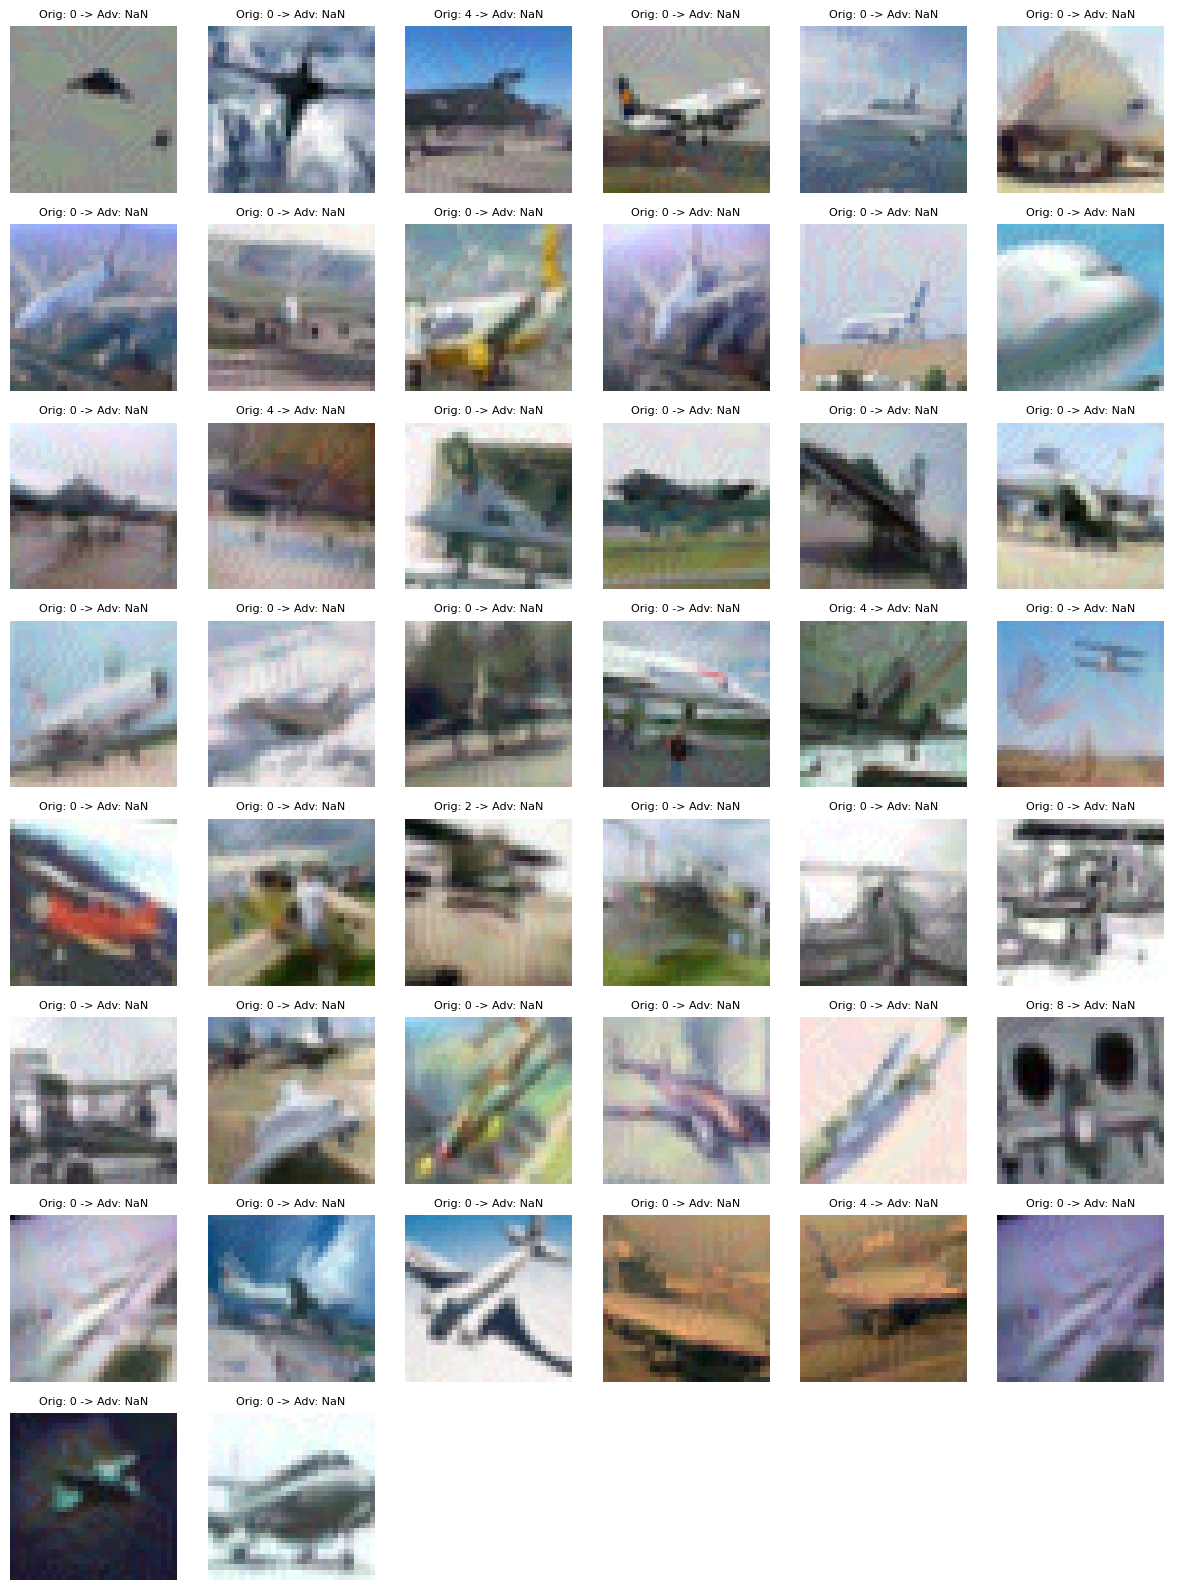

In [46]:
fig = plot_changed_adv_examples(
    adv_examples=adv_examples,
    ref_model=net_orig,
    test_model=net_poly,
    title_prefix="Orig",
    ncols=6,
    max_rows=10,
    show_titles=True,
    print_indices=True,
)

In [47]:
fig.savefig("alexnet_adv.png", dpi=300)

In [48]:
net_inp_min = torch.min(inp)
net_inp_max = torch.max(inp)
net_inp_range = (net_inp_max.item() - net_inp_min.item())

In [51]:
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=(5.0/255.0)*net_inp_range, noise_shape=(3, 32, 32), rotation_scale=True, low=net_inp_min, high=net_inp_max)

In [52]:
attack_layer = "classifier.1.linear.2"
print(f"\nEvaluating for layer: {attack_layer}")
layer_min = net_poly.get_submodule(attack_layer).input_min
layer_max = net_poly.get_submodule(attack_layer).input_max
attack_point = (layer_min + layer_max) / 2.0
adv.loss_strategy = attack.InternalMaxLoss(attack_layer, "reference_model", "input", attack_point=attack_point)
alexnet_adv_eval = attack.robust_eval(net_orig, net_poly, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv, limit=100)


Evaluating for layer: classifier.1.linear.2
 Evaluated 96 samples. Found 8 adversarial examples with NaNs in test model output.

In [53]:
adv_examples = alexnet_adv_eval["adv_examples"]
alexnet_adv_eval["adv_examples"] = None
alexnet_adv_eval

{'normal_loss_ref': 0.053057007757680755,
 'normal_loss_test': 0.052900365952934535,
 'adv_loss_ref': 0.05929233346666608,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.7678571428571429,
 'normal_acc_test': 0.7678571428571429,
 'adv_acc_ref': 0.7589285714285714,
 'adv_acc_test': 0.6517857142857143,
 'normal_eq': 0.9821428571428571,
 'adv_eq': 0.8928571428571429,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.10714285714285714,
 'total': 112,
 'adv_examples': None}

tensor([], dtype=torch.int64)
tensor([15])
tensor([15])
tensor([0, 2, 6])
tensor([0, 2, 6])
tensor([13])
tensor([13])
tensor([ 8, 11])
tensor([ 8, 11])
tensor([11])
tensor([11])
tensor([ 4,  7, 10, 14])
Found 12 changed samples. Displaying...
tensor([ 4,  7, 10, 14])
Found 12 changed samples. Displaying...


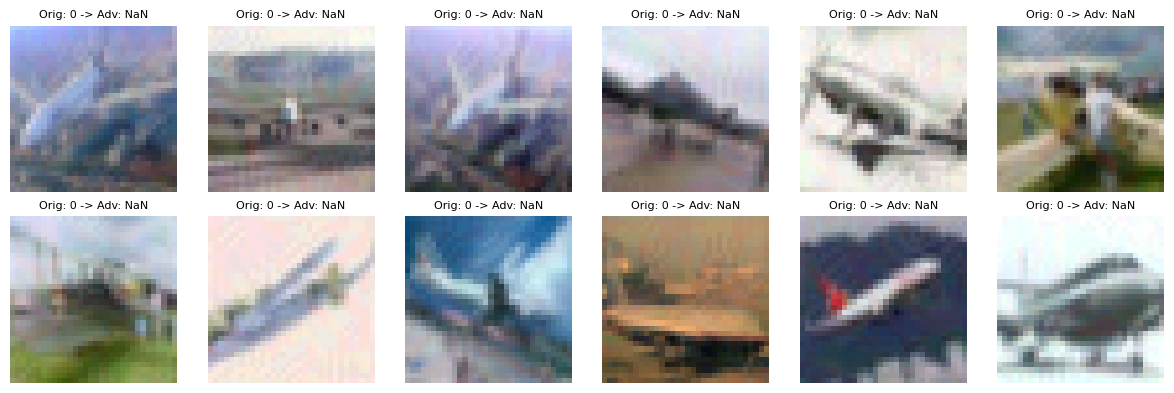

In [54]:
fig = plot_changed_adv_examples(
    adv_examples=adv_examples,
    ref_model=net_orig,
    test_model=net_poly,
    title_prefix="Orig",
    ncols=6,
    max_rows=10,
    show_titles=True,
    print_indices=True,
)

In [55]:
fig.savefig("alexnet_adv_5_div_255.png", dpi=300)

## Resnet

In [56]:
resnet = StandaloneResNet20(dataset='cifar10')
resnet.load_state_dict(torch.load('standalone_resnet20_fitted.pt'))

resnet.eval()

inp, _ = next(iter(testloader))

# use original ReLU activation
resnet.set_polynomial_mode(False)
out_exact = resnet(inp)

# use polynomial approximation
resnet.set_polynomial_mode(True)
out_poly = resnet(inp)

print("exact:     ", out_exact)
print("poly:      ", out_poly)

exact:      tensor([[-3.0220e+00, -3.4836e+00,  9.7019e-01,  1.6847e+01, -2.8400e+00,
          3.5836e+00, -1.1852e+00, -3.4531e+00, -2.7457e+00, -4.6719e+00],
        [ 4.3794e+00,  6.5792e+00, -4.7655e+00, -2.1024e+00, -5.5719e+00,
         -5.3929e+00, -1.1979e+00, -4.6694e+00,  1.4885e+01, -2.1439e+00],
        [ 3.2210e+00,  3.3967e+00, -4.1099e+00, -4.6410e+00, -2.3265e+00,
         -5.7441e+00,  5.1187e-01, -2.0055e+00,  1.1260e+01,  4.3754e-01],
        [ 1.1588e+01,  1.8600e+00, -1.3395e+00, -1.5358e+00, -4.0254e+00,
         -4.1284e+00, -5.3049e+00, -2.8518e+00,  2.8244e+00,  2.9128e+00],
        [-4.0149e+00, -9.4121e-02,  1.6633e+00,  1.5942e-01, -2.2121e-01,
         -1.9939e+00,  1.3677e+01, -4.8439e+00, -2.9465e+00, -1.3853e+00],
        [-4.9891e+00, -4.0880e+00, -3.2786e+00,  2.1108e+00, -2.6929e-03,
          1.3561e+00,  1.2967e+01, -1.0651e+00, -2.0351e+00, -9.7542e-01],
        [ 1.2854e+00,  7.8519e+00,  7.4051e-02,  9.5073e-01, -4.3395e+00,
         -1.3203e+00

In [57]:
ranges = get_and_print_poly_ranges(resnet)

Idx  | Module Name                         | Estimated Input Domain [a, b]
--------------------------------------------------------------------------
1    | act                                 | [-4.435101, 4.794806]
2    | layers.0.0.act1                     | [-3.311713, 2.380607]
3    | layers.0.0.act2                     | [-3.781689, 6.041824]
4    | layers.0.1.act1                     | [-3.882738, 2.933398]
5    | layers.0.1.act2                     | [-4.096857, 5.953842]
6    | layers.0.2.act1                     | [-2.888341, 2.276461]
7    | layers.0.2.act2                     | [-2.586878, 6.186315]
8    | layers.1.0.act1                     | [-2.908145, 2.937944]
9    | layers.1.0.act2                     | [-4.161288, 5.758540]
10   | layers.1.1.act1                     | [-3.107396, 2.052485]
11   | layers.1.1.act2                     | [-3.159743, 5.974730]
12   | layers.1.2.act1                     | [-2.434087, 2.462888]
13   | layers.1.2.act2                     | [

In [58]:
resnet.set_polynomial_mode(False)
resnet_orig = copy.deepcopy(resnet)
resnet.set_polynomial_mode(True)
resnet_poly = copy.deepcopy(resnet)

In [59]:
acc_orig, correct_orig, total_orig = evaluate_accuracy(resnet_orig, testloader, device="cpu", limit=100)
acc_poly, correct_poly, total_poly = evaluate_accuracy(resnet_poly, testloader, device="cpu", limit=100)

print(f"resnet_orig accuracy: {acc_orig:.4%} ({correct_orig}/{total_orig})")
print(f"resnet_poly accuracy: {acc_poly:.4%} ({correct_poly}/{total_poly})")

resnet_orig accuracy: 94.6429% (106/112)
resnet_poly accuracy: 93.7500% (105/112)


In [62]:
net_inp_min = torch.min(inp)
net_inp_max = torch.max(inp)
net_inp_range = (net_inp_max.item() - net_inp_min.item())

In [63]:
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=(5.0/255.0)*net_inp_range, noise_shape=(3, 32, 32), rotation_scale=True, low=net_inp_min, high=net_inp_max)

In [64]:
attack_layer = "layers.2.2.act2"
print(f"\nEvaluating for layer: {attack_layer}")
layer_min = resnet_poly.get_submodule(attack_layer).input_min
layer_max = resnet_poly.get_submodule(attack_layer).input_max
attack_point = (layer_min + layer_max) / 2.0
adv.loss_strategy = attack.InternalMaxLoss(attack_layer, "reference_model", "input", attack_point=attack_point)
resnet_adv_eval = attack.robust_eval(resnet_orig, resnet_poly, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv, limit=100)


Evaluating for layer: layers.2.2.act2


/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 Evaluated 96 samples. Found 17 adversarial examples with NaNs in test model output.

In [65]:
torch.save(resnet_adv_eval, "resnet20_adv_search.pt")

In [66]:
resnet_adv_eval = torch.load("resnet20_adv_search.pt", map_location="cpu")

In [67]:
adv_examples = resnet_adv_eval["adv_examples"]
resnet_adv_eval["adv_examples"] = None
resnet_adv_eval

{'normal_loss_ref': 0.036492944562009404,
 'normal_loss_test': 0.037270855358136554,
 'adv_loss_ref': 1.0070082715579443,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.8392857142857143,
 'normal_acc_test': 0.8392857142857143,
 'adv_acc_ref': 0.026785714285714284,
 'adv_acc_test': 0.017857142857142856,
 'normal_eq': 1.0,
 'adv_eq': 0.8392857142857143,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.15178571428571427,
 'total': 112,
 'adv_examples': None}

tensor([ 2,  5,  9, 13])
tensor([1])
tensor([10, 12, 15])
tensor([ 5, 14])
tensor([ 3,  8, 10, 11, 12, 14])
tensor([ 5, 14])
tensor([ 3,  8, 10, 11, 12, 14])
tensor([6])
tensor([], dtype=torch.int64)
Found 17 changed samples. Displaying...
tensor([6])
tensor([], dtype=torch.int64)
Found 17 changed samples. Displaying...


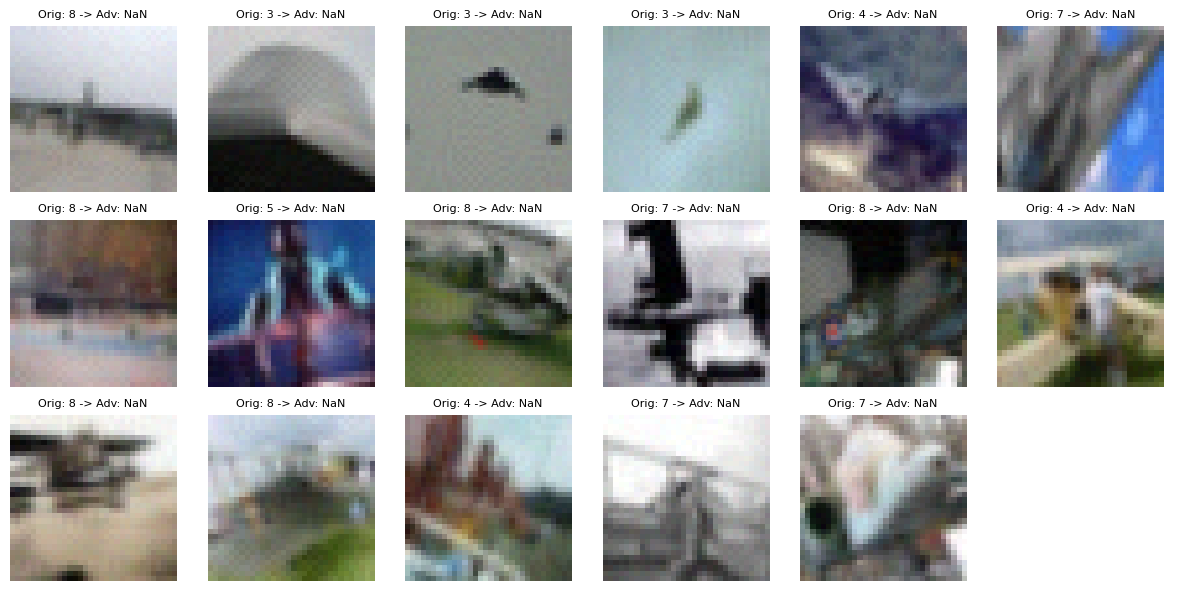

In [69]:
fig = plot_changed_adv_examples(
    adv_examples=adv_examples,
    ref_model=resnet_orig,
    test_model=resnet_poly,
    title_prefix="Orig",
    ncols=6,
    max_rows=10,
    show_titles=True,
    print_indices=True,
)

In [70]:
fig.savefig("resnet_adv_5_div_255.png", dpi=300)